Data handing libraries

In [1]:
import numpy as np
import pandas as pd

Visulization Libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

Helper library

In [3]:
import warnings
warnings.filterwarnings("ignore")

Data spliting

In [4]:
from sklearn.model_selection import train_test_split

To build Pipelines

In [5]:
from sklearn.pipeline import Pipeline

Preprocessing libraries for (Scaling/ Encoding/ Imputation)

In [6]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder,MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

Model building Libraries

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

Matics/ which are used to evaluate the performance of your machine learning models

In [8]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix, classification_report

Resampling (handing imblance in data)

In [9]:
from imblearn.over_sampling import SMOTE

Hyperparamater Tuning Library

In [10]:
from sklearn.model_selection import GridSearchCV

 # 1. Exploratory Data Analysis (EDA)
### 1.1 Check dataset shape, data types, missing values, and unique values.


In [11]:
df=pd.read_csv("C:/Users/ASUS/Downloads/synthetic_dataset_10000x20.csv")
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


In [12]:
# to check null values 

In [13]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [14]:
df.drop("customer_id",axis=1,inplace=True)

In [15]:
df.drop("signup_date",axis=1,inplace=True)

In [16]:
df["education"]=df["education"].replace("Bachlors","Bachelors")
# One bar for "Bachelors"  Another tiny bar for "Bachlors"
#That’s misleading because they’re supposed to represent the same education level.
#After doing this, value_counts() will correctly show only "Bachelors" with total (4443 + 87 = 4530).

In [17]:
df.isnull().sum()

age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [18]:
# X(feature/input Variable)
# Y(Target variable)
#to build a predictive model that learns from the relationship between X (customer characteristics) and Y (target_default_risk).
X=df.drop("target_default_risk",axis=1)
Y=df["target_default_risk"]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  int64  
 1   income               9682 non-null   float64
 2   savings              9689 non-null   float64
 3   monthly_expenses     9675 non-null   float64
 4   num_dependents       10000 non-null  int64  
 5   credit_score         9674 non-null   float64
 6   loan_amount          10000 non-null  float64
 7   loan_term_months     10000 non-null  int64  
 8   employment_years     10000 non-null  float64
 9   home_ownership       10000 non-null  object 
 10  education            10000 non-null  object 
 11  marital_status       10000 non-null  object 
 12  region               10000 non-null  object 
 13  recent_default       10000 non-null  int64  
 14  has_credit_card      10000 non-null  int64  
 15  signup_dayofweek     10000 non-null  

In [20]:
# it counts the number of unique values in each column of a DataFrame, nunique() just gives you the count.
df.nunique()

age                      57
income                 9107
savings                6498
monthly_expenses       3068
num_dependents            8
credit_score           9647
loan_amount            7999
loan_term_months          6
employment_years        182
home_ownership            4
education                 5
marital_status            4
region                    4
recent_default            2
has_credit_card           2
signup_dayofweek          7
debt_to_income         1261
sin_age                  57
target_default_risk       2
dtype: int64

### 1.2 plot distribution of numerical features(Histogram)

In [21]:
# A histogram shows the distribution of numerical data. And it divides values into bins (intervals) and counts how many data points fall in each bin.
# it helps for Data preprocessing which means it helps to decide transformation line(normalization,Scaling)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'savings'}>,
        <Axes: title={'center': 'monthly_expenses'}>],
       [<Axes: title={'center': 'num_dependents'}>,
        <Axes: title={'center': 'credit_score'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'loan_term_months'}>],
       [<Axes: title={'center': 'employment_years'}>,
        <Axes: title={'center': 'recent_default'}>,
        <Axes: title={'center': 'has_credit_card'}>,
        <Axes: title={'center': 'signup_dayofweek'}>],
       [<Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'sin_age'}>,
        <Axes: title={'center': 'target_default_risk'}>, <Axes: >]],
      dtype=object)

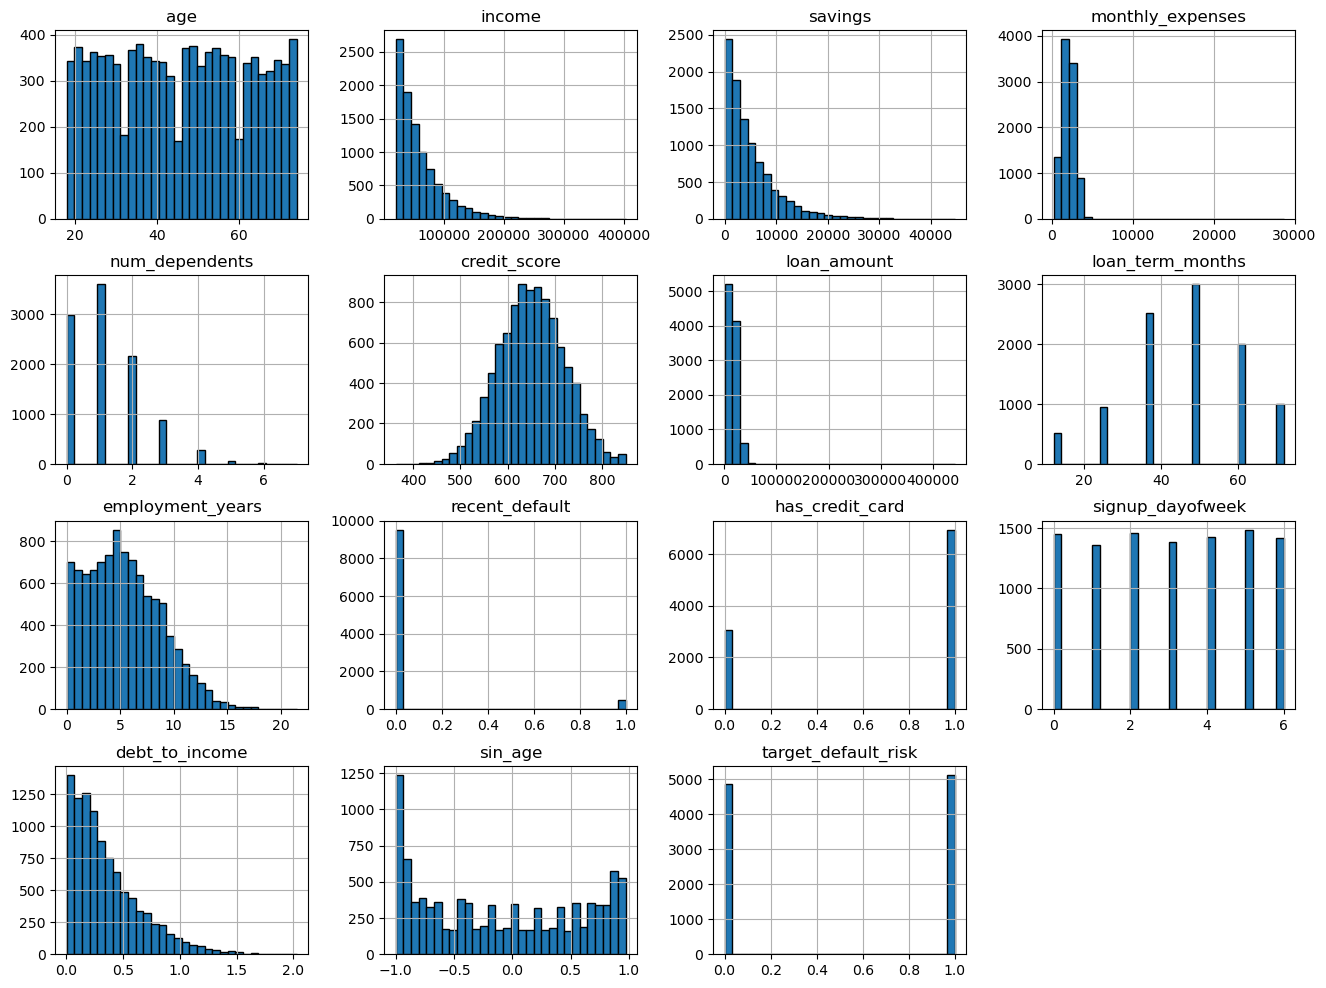

In [22]:
df.hist(figsize = (16,12),bins=30,edgecolor="black")
# bins=5 → divides the range into 5 intervals (0–20k, 20k–40k, …).
# bins=30 → divides the range into 30 intervals.(about 3k width each)

### 1.3 Analyze categorical variables (bar charts, value counts)

In [23]:
df["education"].value_counts()
# count(value) = number of times that value appears in the column
#Example:
# Column: ["A", "B", "A", "C", "B", "A"] (A → 3 times) (B → 2 times) (C → 1 time)

education
Bachelors    4530
HS           2546
Masters      1962
Other         500
PhD           462
Name: count, dtype: int64

In [24]:
for col in df.columns:
    print(df[col].value_counts())#It loops through every column in your DataFrame (df.columns).
# for each column ,it runs(.value_counts(),,and it will show how many times each unique value appears in column.
# we'll do this to understand the distribution of values in each column.

age
73    209
54    209
53    199
36    194
34    192
48    191
46    190
25    189
21    187
20    186
58    186
35    186
49    185
26    185
38    182
32    182
28    182
63    181
74    181
40    180
47    180
70    179
56    178
50    177
19    177
57    177
22    177
42    176
33    174
60    174
24    174
29    174
71    172
64    170
45    170
37    170
61    169
30    169
62    169
31    168
27    168
66    167
23    166
69    166
59    165
72    165
18    165
43    164
52    164
41    164
55    163
68    163
39    162
67    159
51    154
65    148
44    147
Name: count, dtype: int64
income
20702.0    4
21232.0    4
74178.0    3
23029.0    3
60685.0    3
          ..
44865.0    1
37348.0    1
45584.0    1
38884.0    1
38273.0    1
Name: count, Length: 9107, dtype: int64
savings
1308.0     8
275.0      7
956.0      6
274.0      6
362.0      6
          ..
12527.0    1
4065.0     1
10641.0    1
9616.0     1
6201.0     1
Name: count, Length: 6498, dtype: int64
monthly_expenses
20

Text(0.5, 1.0, 'Average Loan Amount for Education')

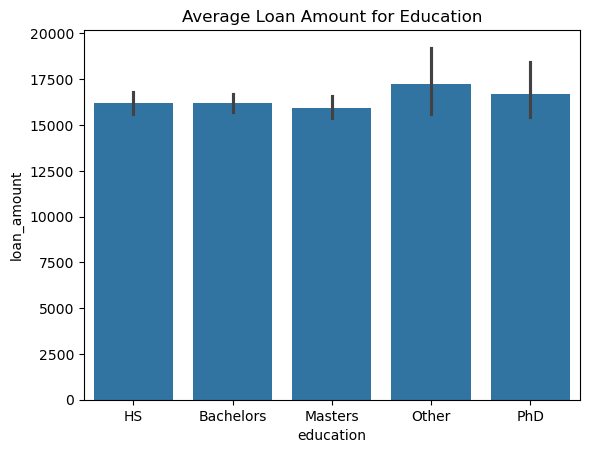

In [25]:
sns.barplot(x="education",y="loan_amount",data=df)
plt.title("Average Loan Amount for Education")

Text(0.5, 1.0, 'Average savings on Income')

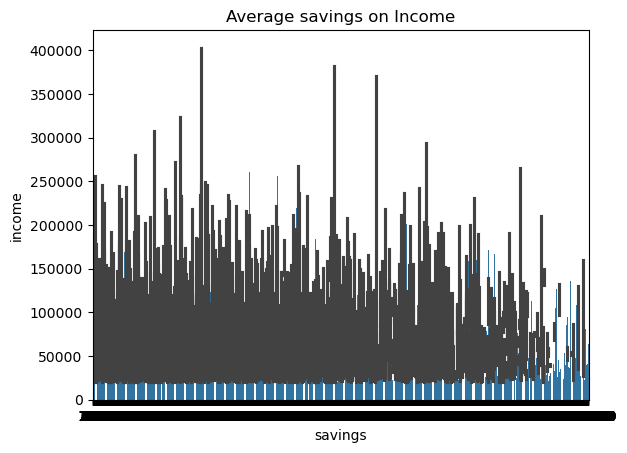

In [26]:
sns.barplot(x="savings",y="income",data=df)
plt.title ("Average savings on Income")

([0, 1, 2, 3],
 [Text(0, 0, 'Single'),
  Text(1, 0, 'Married'),
  Text(2, 0, 'Divorced'),
  Text(3, 0, 'Widowed')])

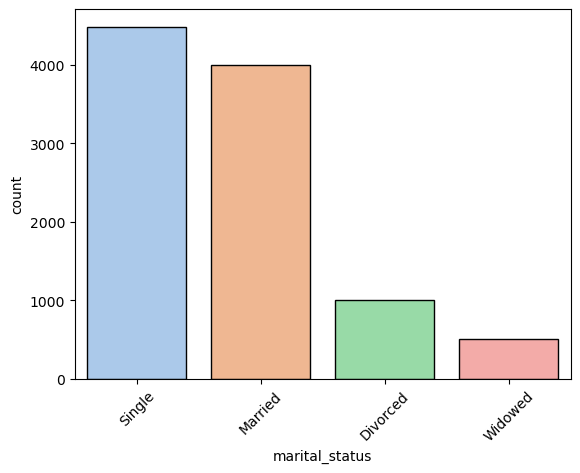

In [27]:
sns.countplot(x=df["marital_status"],palette = "pastel",edgecolor="black")
plt.xticks(rotation=45)
#In Seaborn, countplot is a type of bar plot that shows the number of occurrences (counts) of each category in a categorical variable.
# palette = "pastel" it is for colouring for eack box
# xticks= is it labling 
# rotation=45 ==(rotates the labels 45 degrees)

([0, 1, 2, 3],
 [Text(0, 0, 'West'),
  Text(1, 0, 'East'),
  Text(2, 0, 'South'),
  Text(3, 0, 'North')])

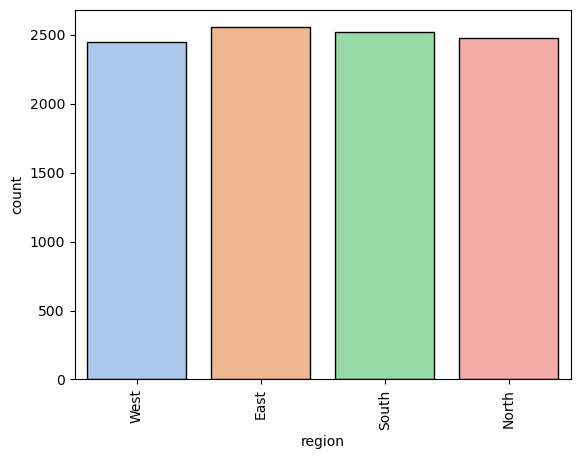

In [28]:
sns.countplot(x=df["region"],palette = "pastel",edgecolor="black")
plt.xticks(rotation=90 )

Text(0.5, 1.0, 'Average loan Amount for Education and region')

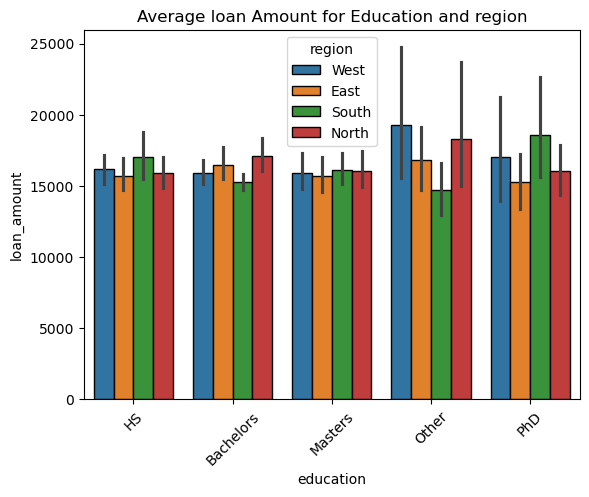

In [29]:
sns.barplot(x=df["education"],y=df["loan_amount"],hue=df["region"],edgecolor="black")
plt.xticks(rotation=45)
plt.title("Average loan Amount for Education and region")

#hue=df["region"] → within each education group, bars are further split by region, shown in different colors.
# So instead of one bar per education level, you’ll see multiple bars (one for each region) side by side for easier comparison.

Text(0.5, 1.0, 'Average loan Amount for Education and region')

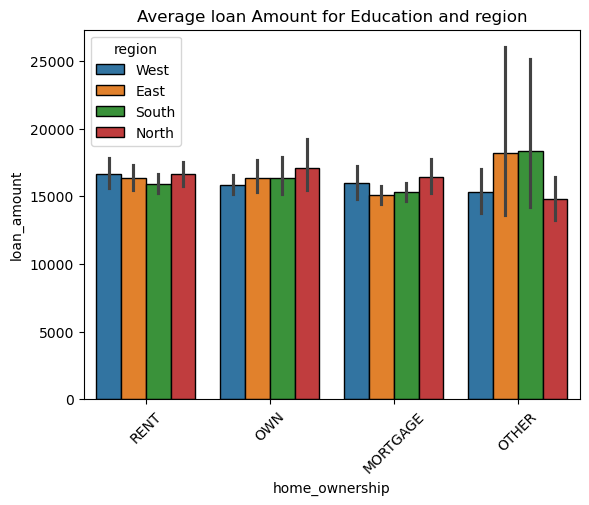

In [30]:
sns.barplot(x=df["home_ownership"],y=df["loan_amount"],hue=df["region"],edgecolor="black")
plt.xticks(rotation=45)
plt.title("Average loan Amount for Education and region")

Text(0.5, 1.0, 'Average loan Amount for Education and region')

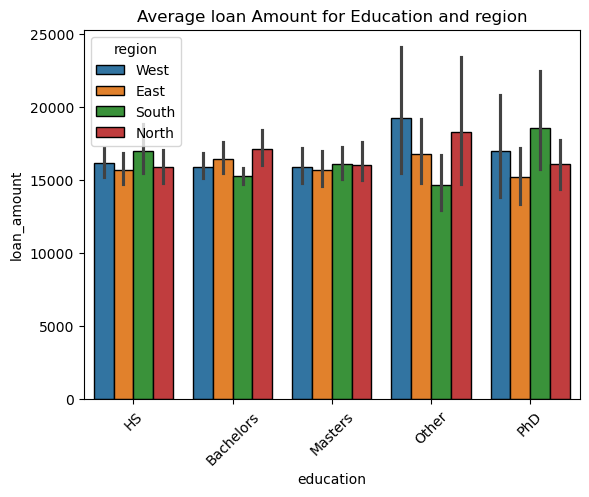

In [31]:
sns.barplot(x=df["education"],y=df["loan_amount"],hue=df["region"],edgecolor="black")
plt.xticks(rotation=45)
plt.title("Average loan Amount for Education and region")

### 1.4 detect outliers strategies to handle

In [32]:
# Seperate numerical and categorical columns
num_cols = X.select_dtypes(include=["int64","float64"],).columns
cat_cols=X.select_dtypes(include=["object"]).columns

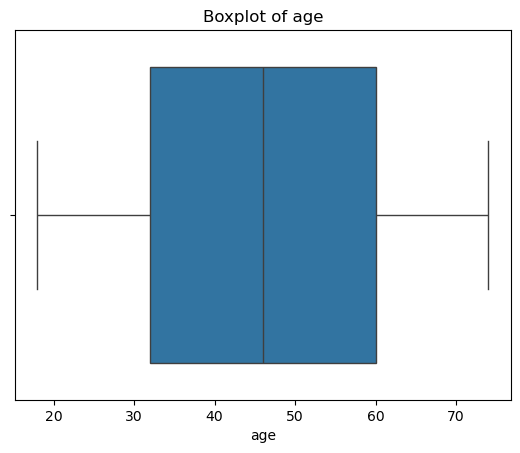

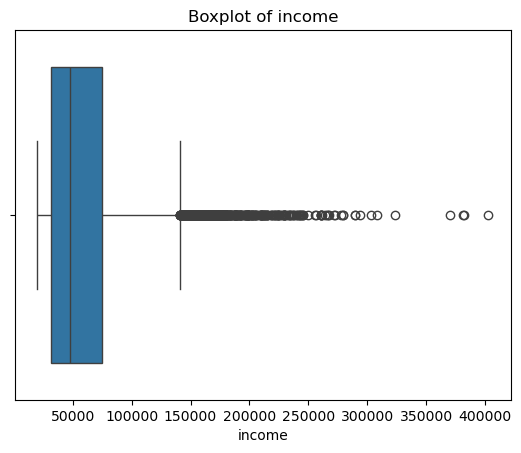

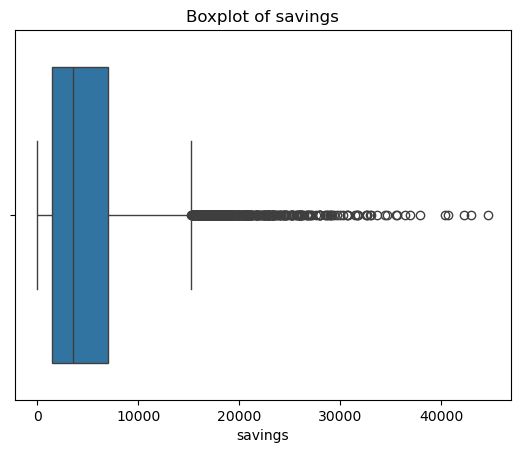

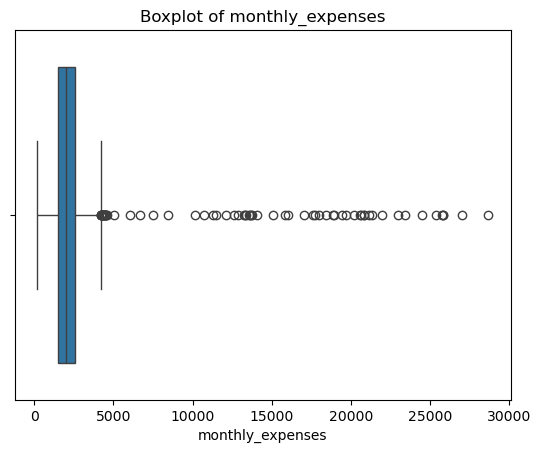

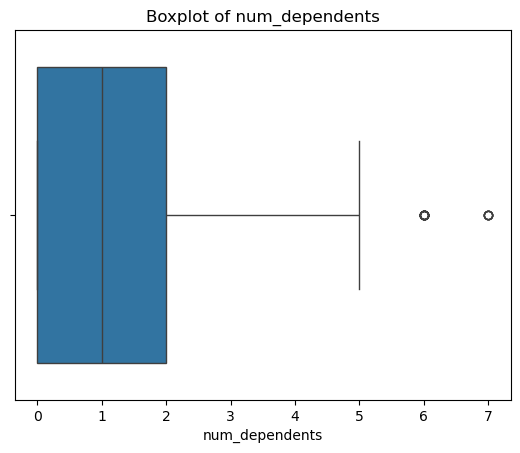

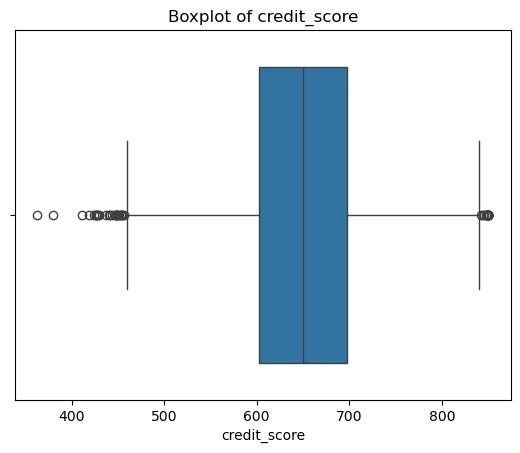

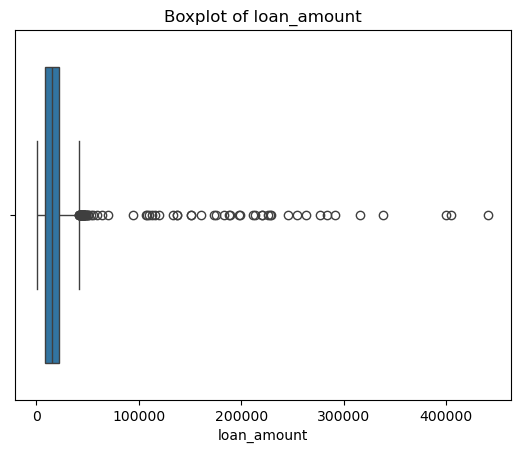

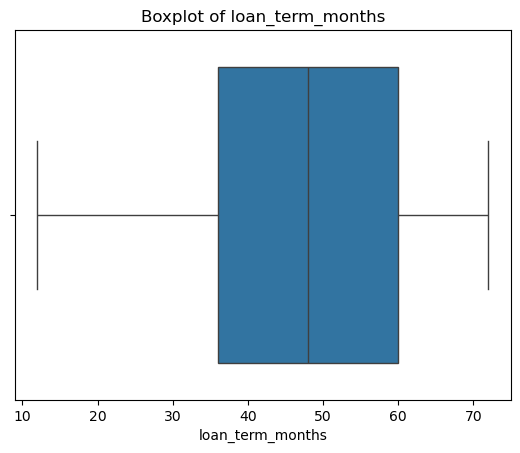

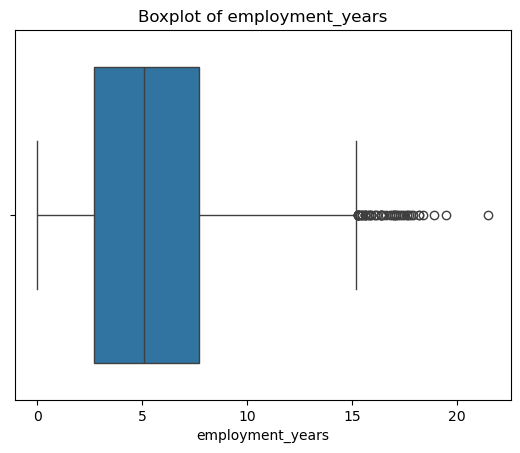

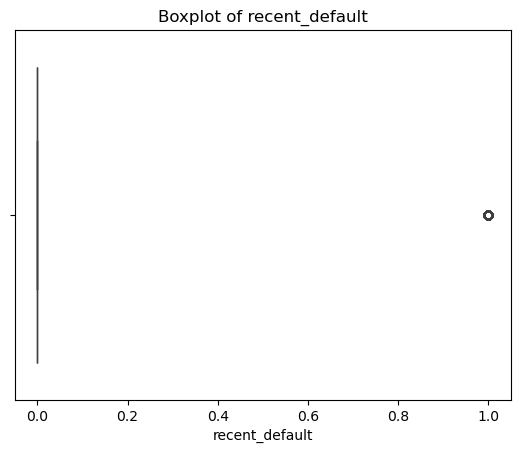

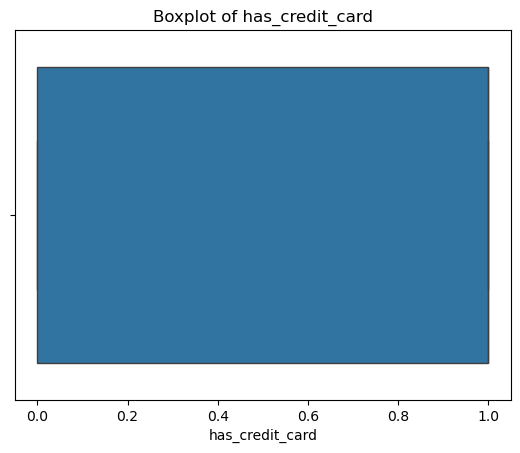

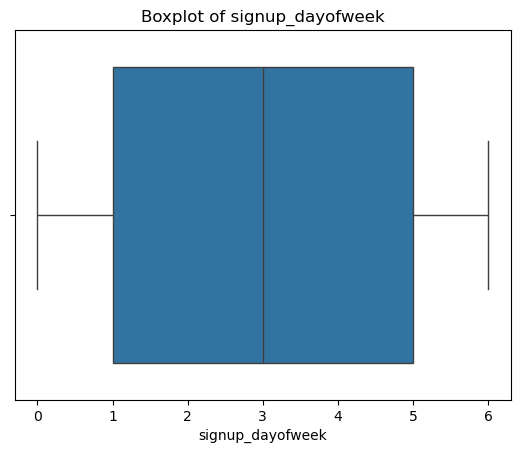

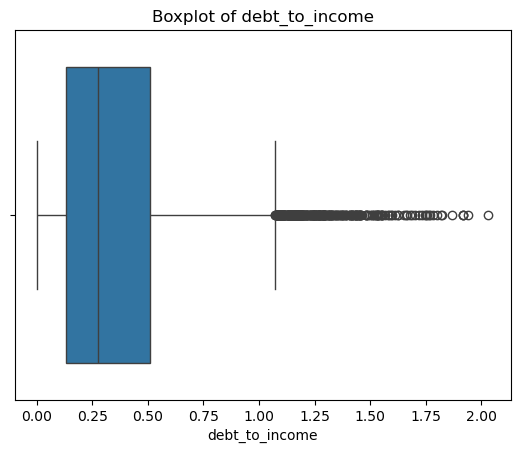

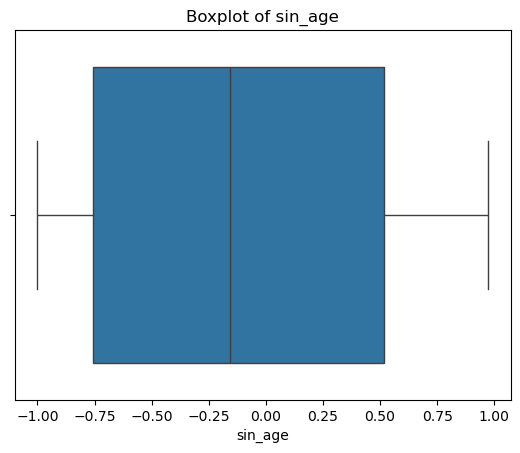

In [33]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
# num_cols For each column draws a boxplot of its values.

<Axes: >

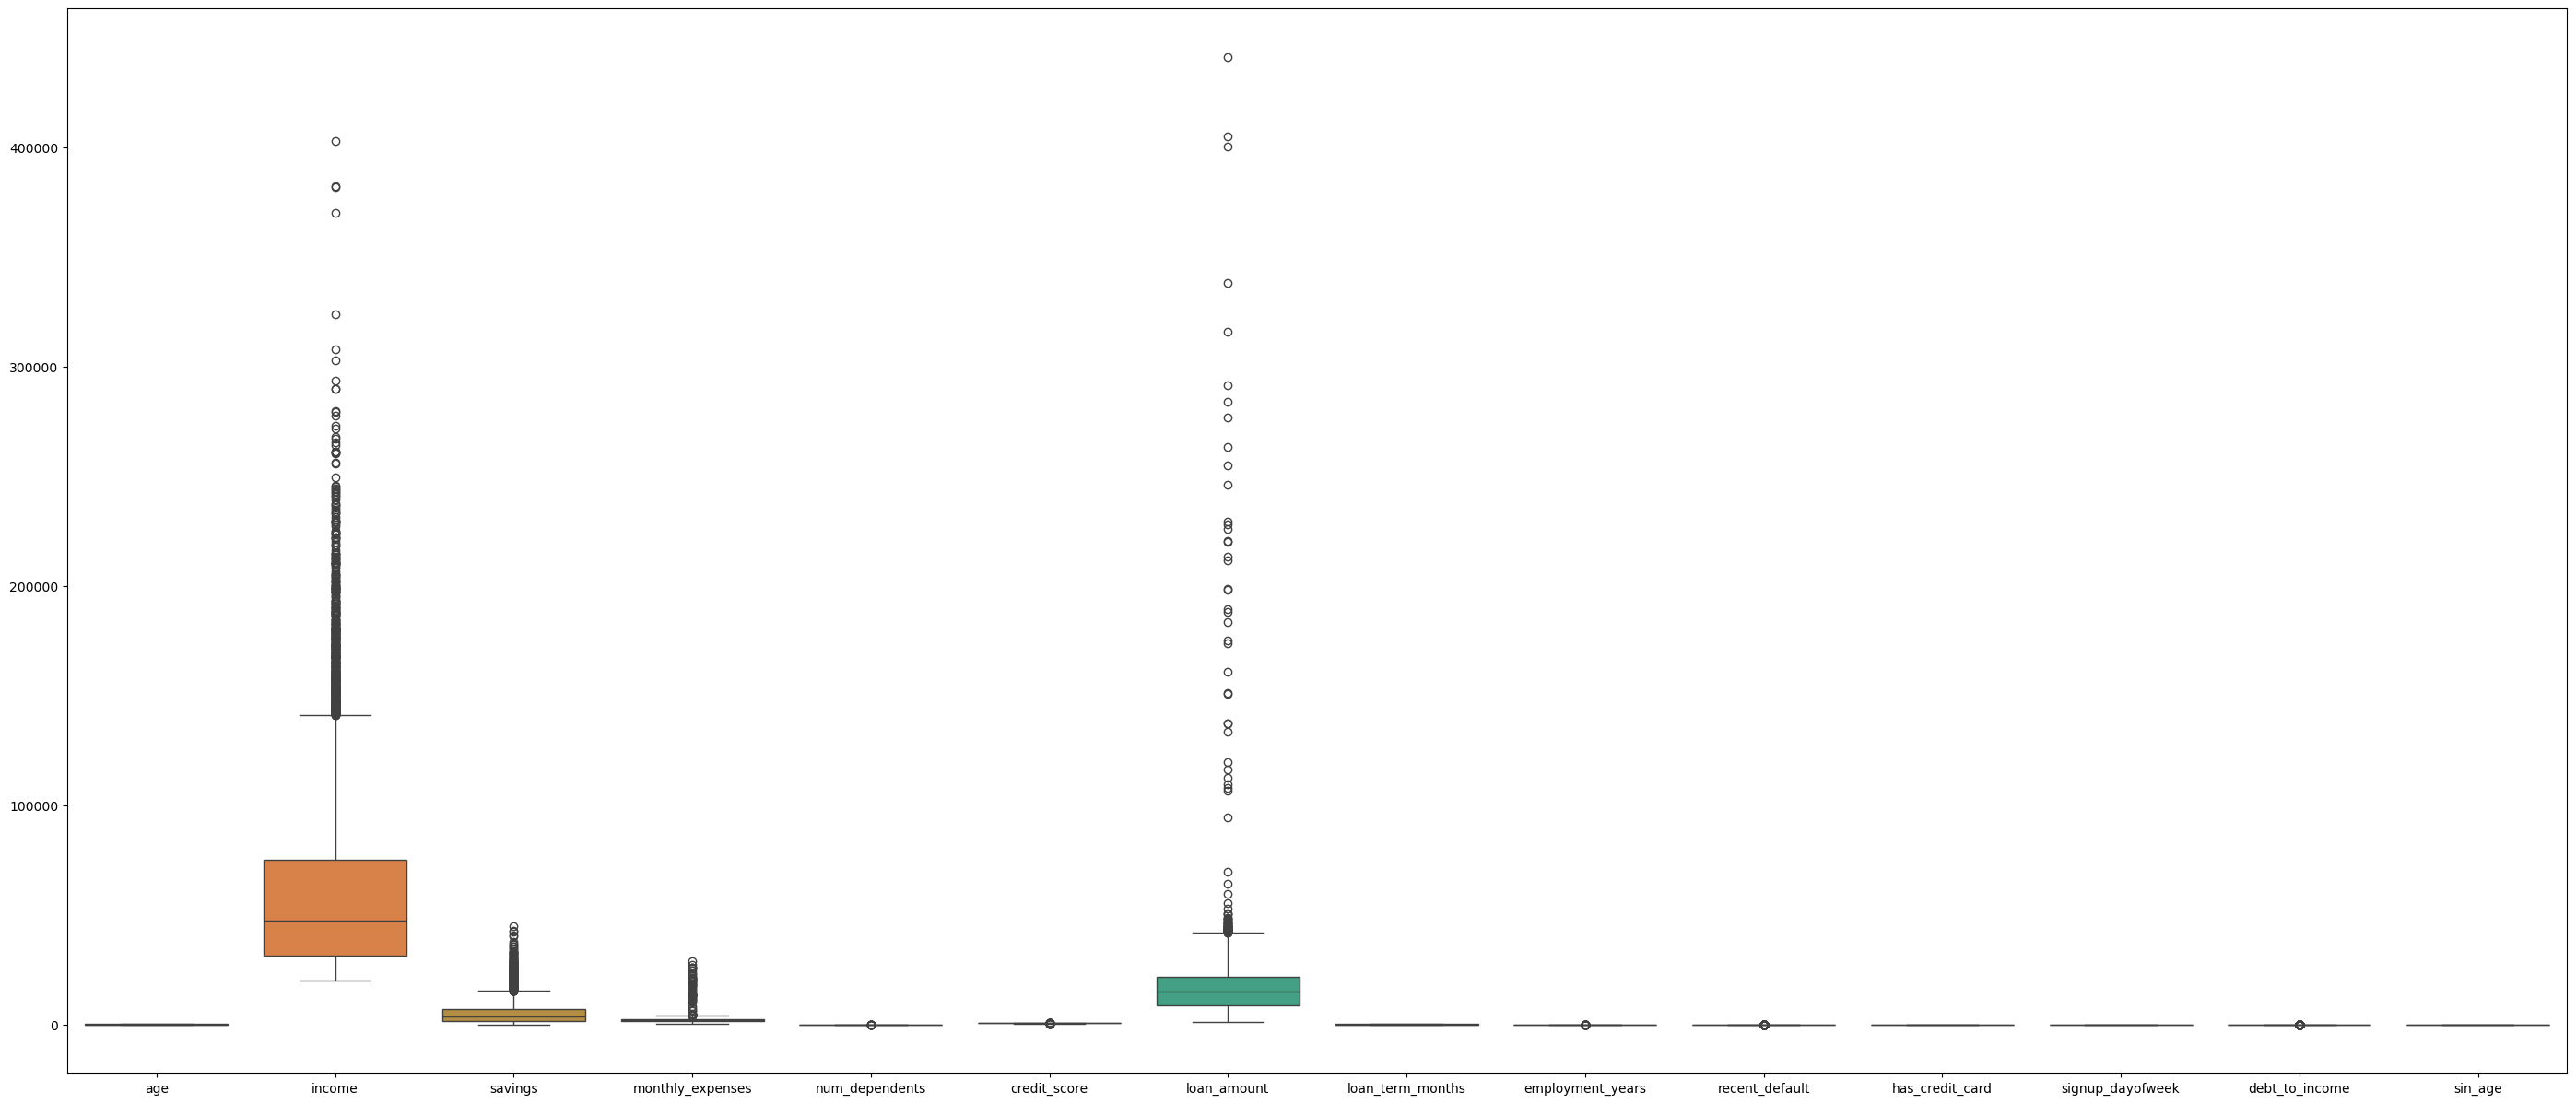

In [34]:
plt.figure(figsize=(35,15))
sns.boxplot(data=df[num_cols])
# we can see all outliers in singleplot virticaly

In [35]:
# How to find OutLiners
# two methods (1.IQR)  > use this method when the data is not normal
            # (3_Sigma Rules) > use this method when the data is normal

In [36]:
for col in num_cols:
    Q1 =df[col].quantile(0.25)
    Q3 =df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_limit = Q1-1.5*IQR
    upper_limit = Q3+1.5*IQR
    df[col]=df[col].clip(lower=lower_limit,upper=upper_limit) 

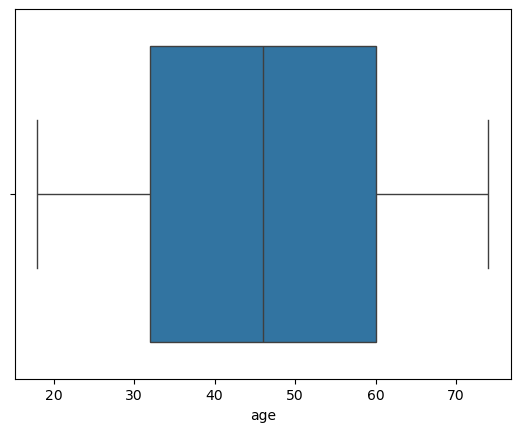

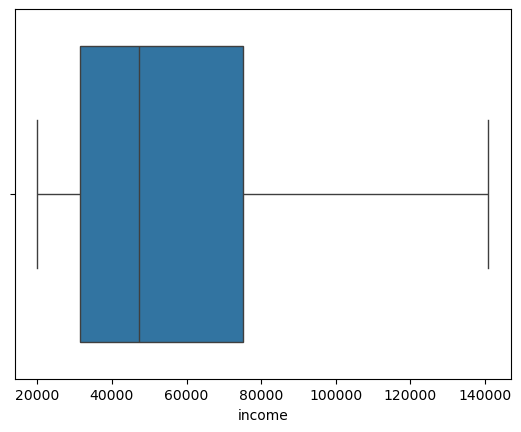

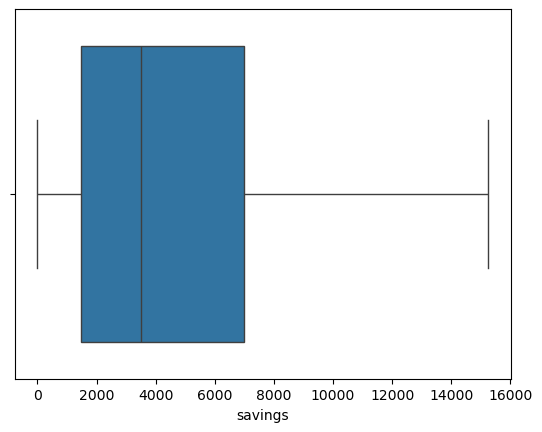

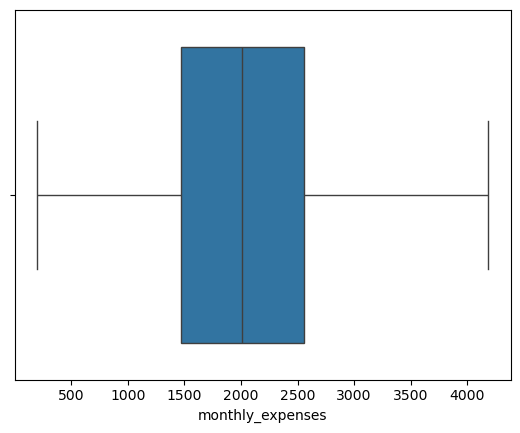

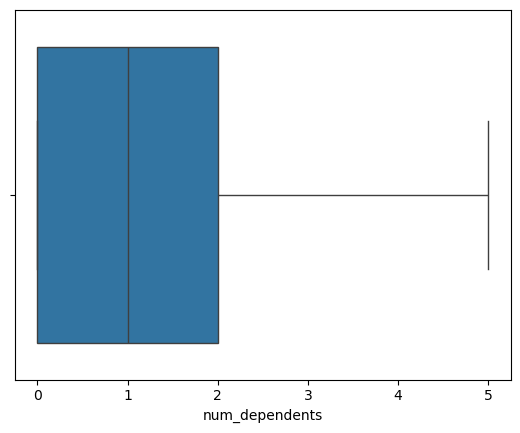

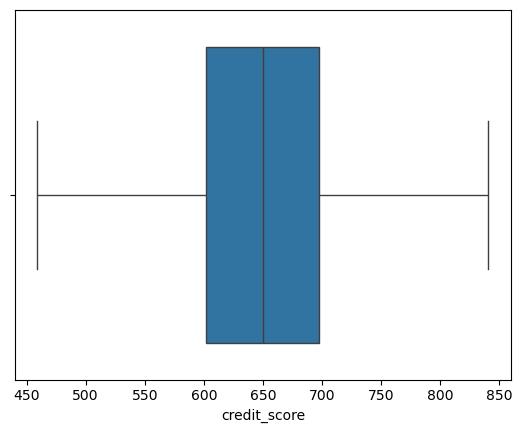

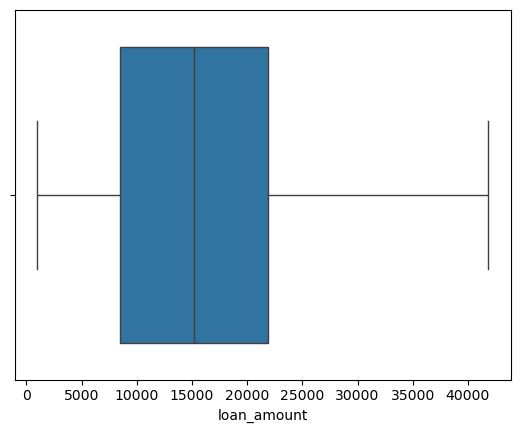

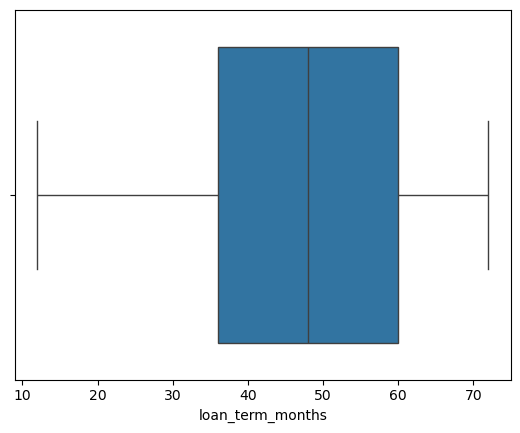

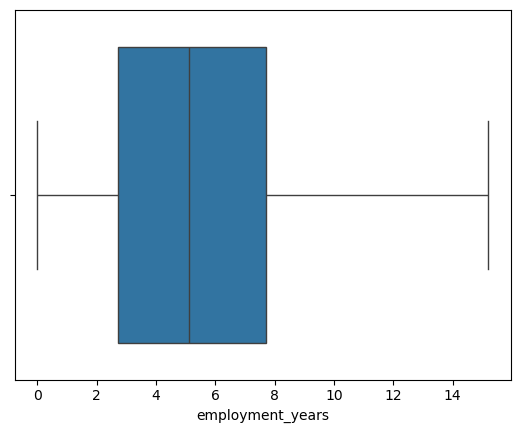

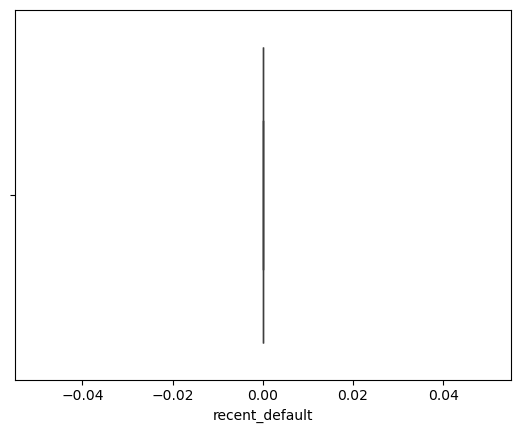

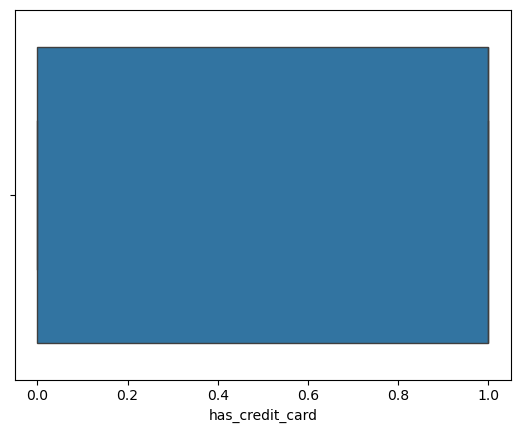

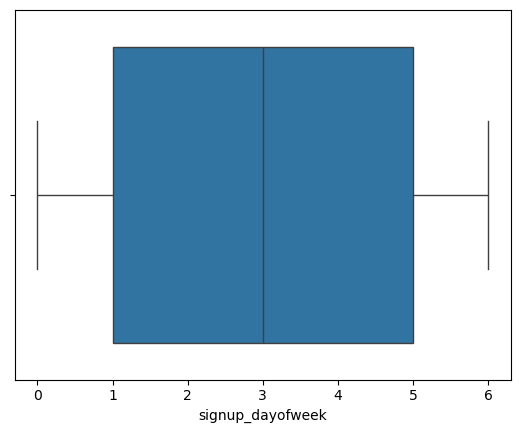

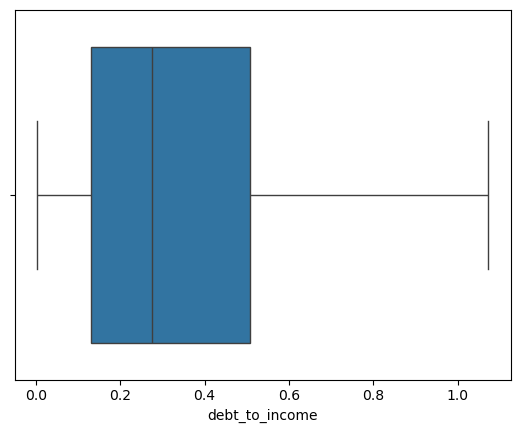

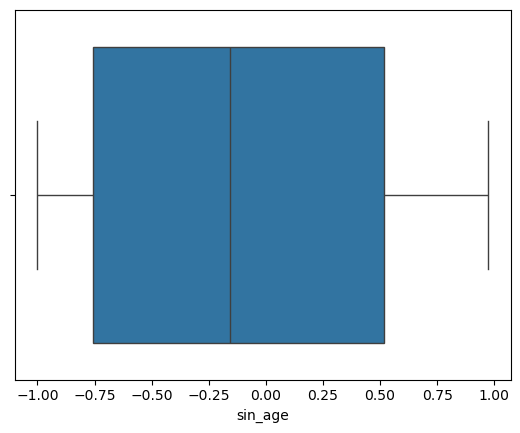

In [37]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()
# After removing the Outliers

### 1.5 heatmap and pair plot

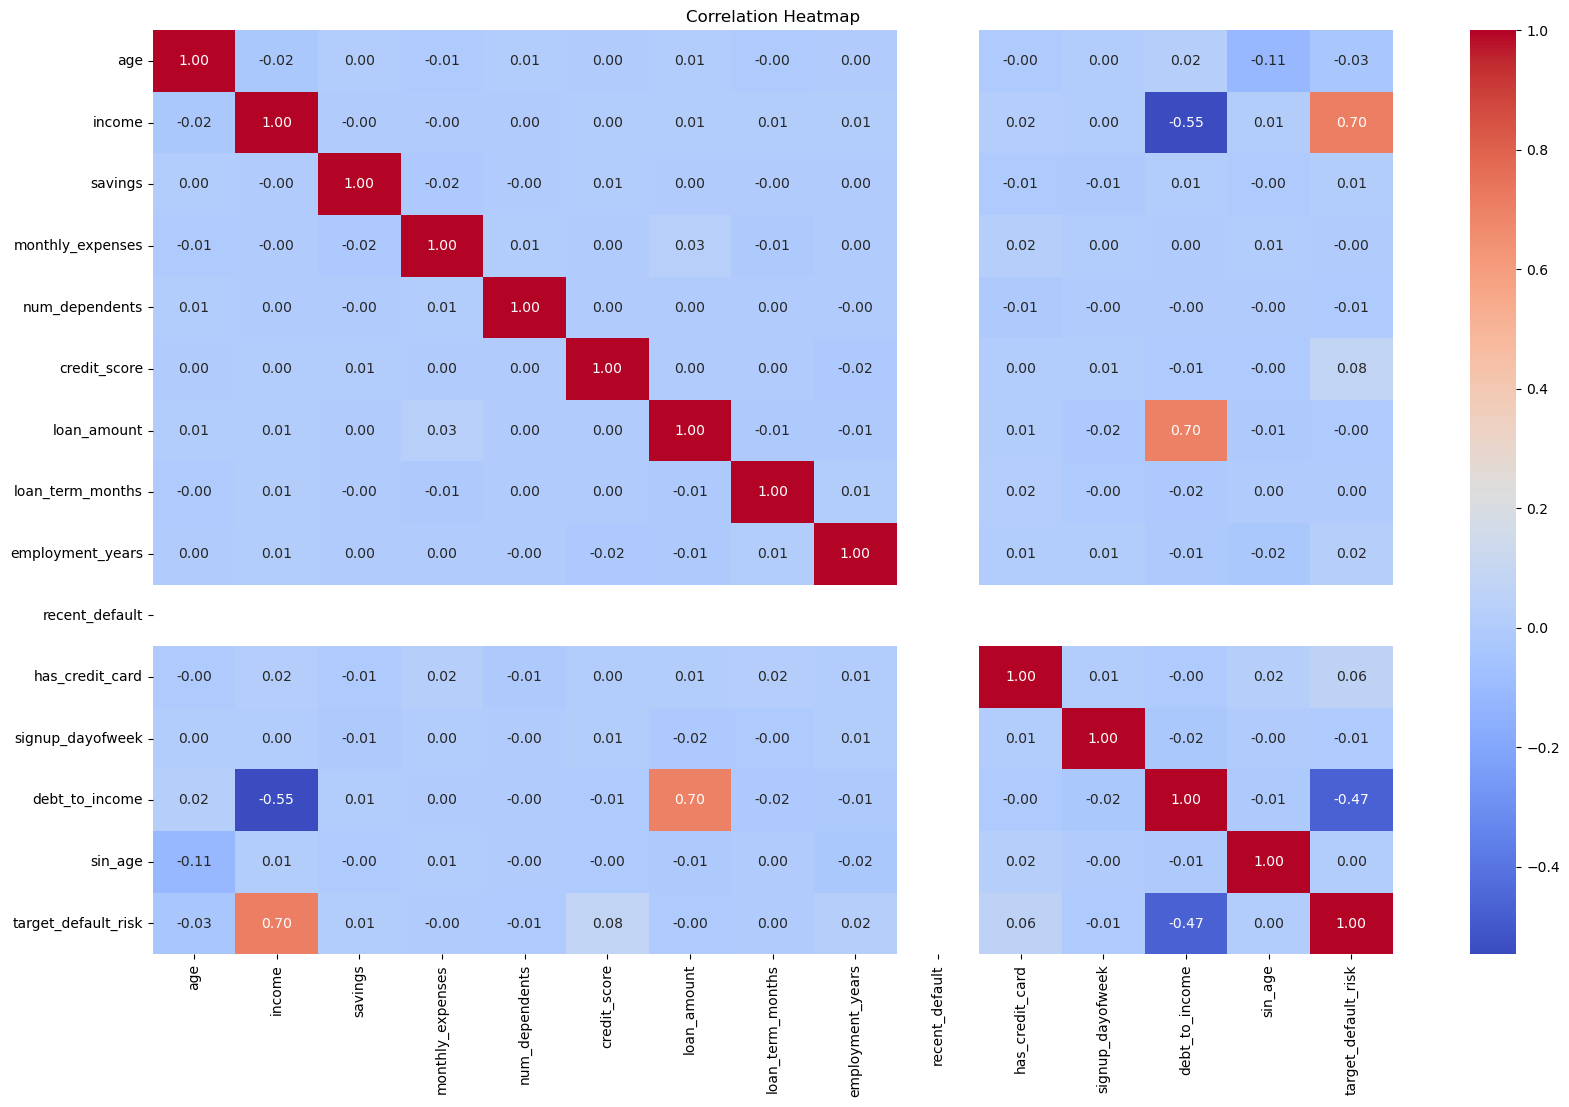

In [38]:
corr = df.select_dtypes(include=["int64","float64"]).corr()
plt.figure(figsize=(20,12))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()
#cmap=collwarm  (colour scheme)
#Without annot=True → the heatmap is just colors. You can see which cells are dark or light, but you don’t know the exact correlation number.
#With annot=True → Seaborn writes the actual correlation value inside each square of the heatmap.
#Without fmt, the numbers might look messy (too many decimals).(0.825467,0.264356,0.33333)
#with A correlation value of 0.824617 , -0.333333→ will display as 0.82, 0.33 


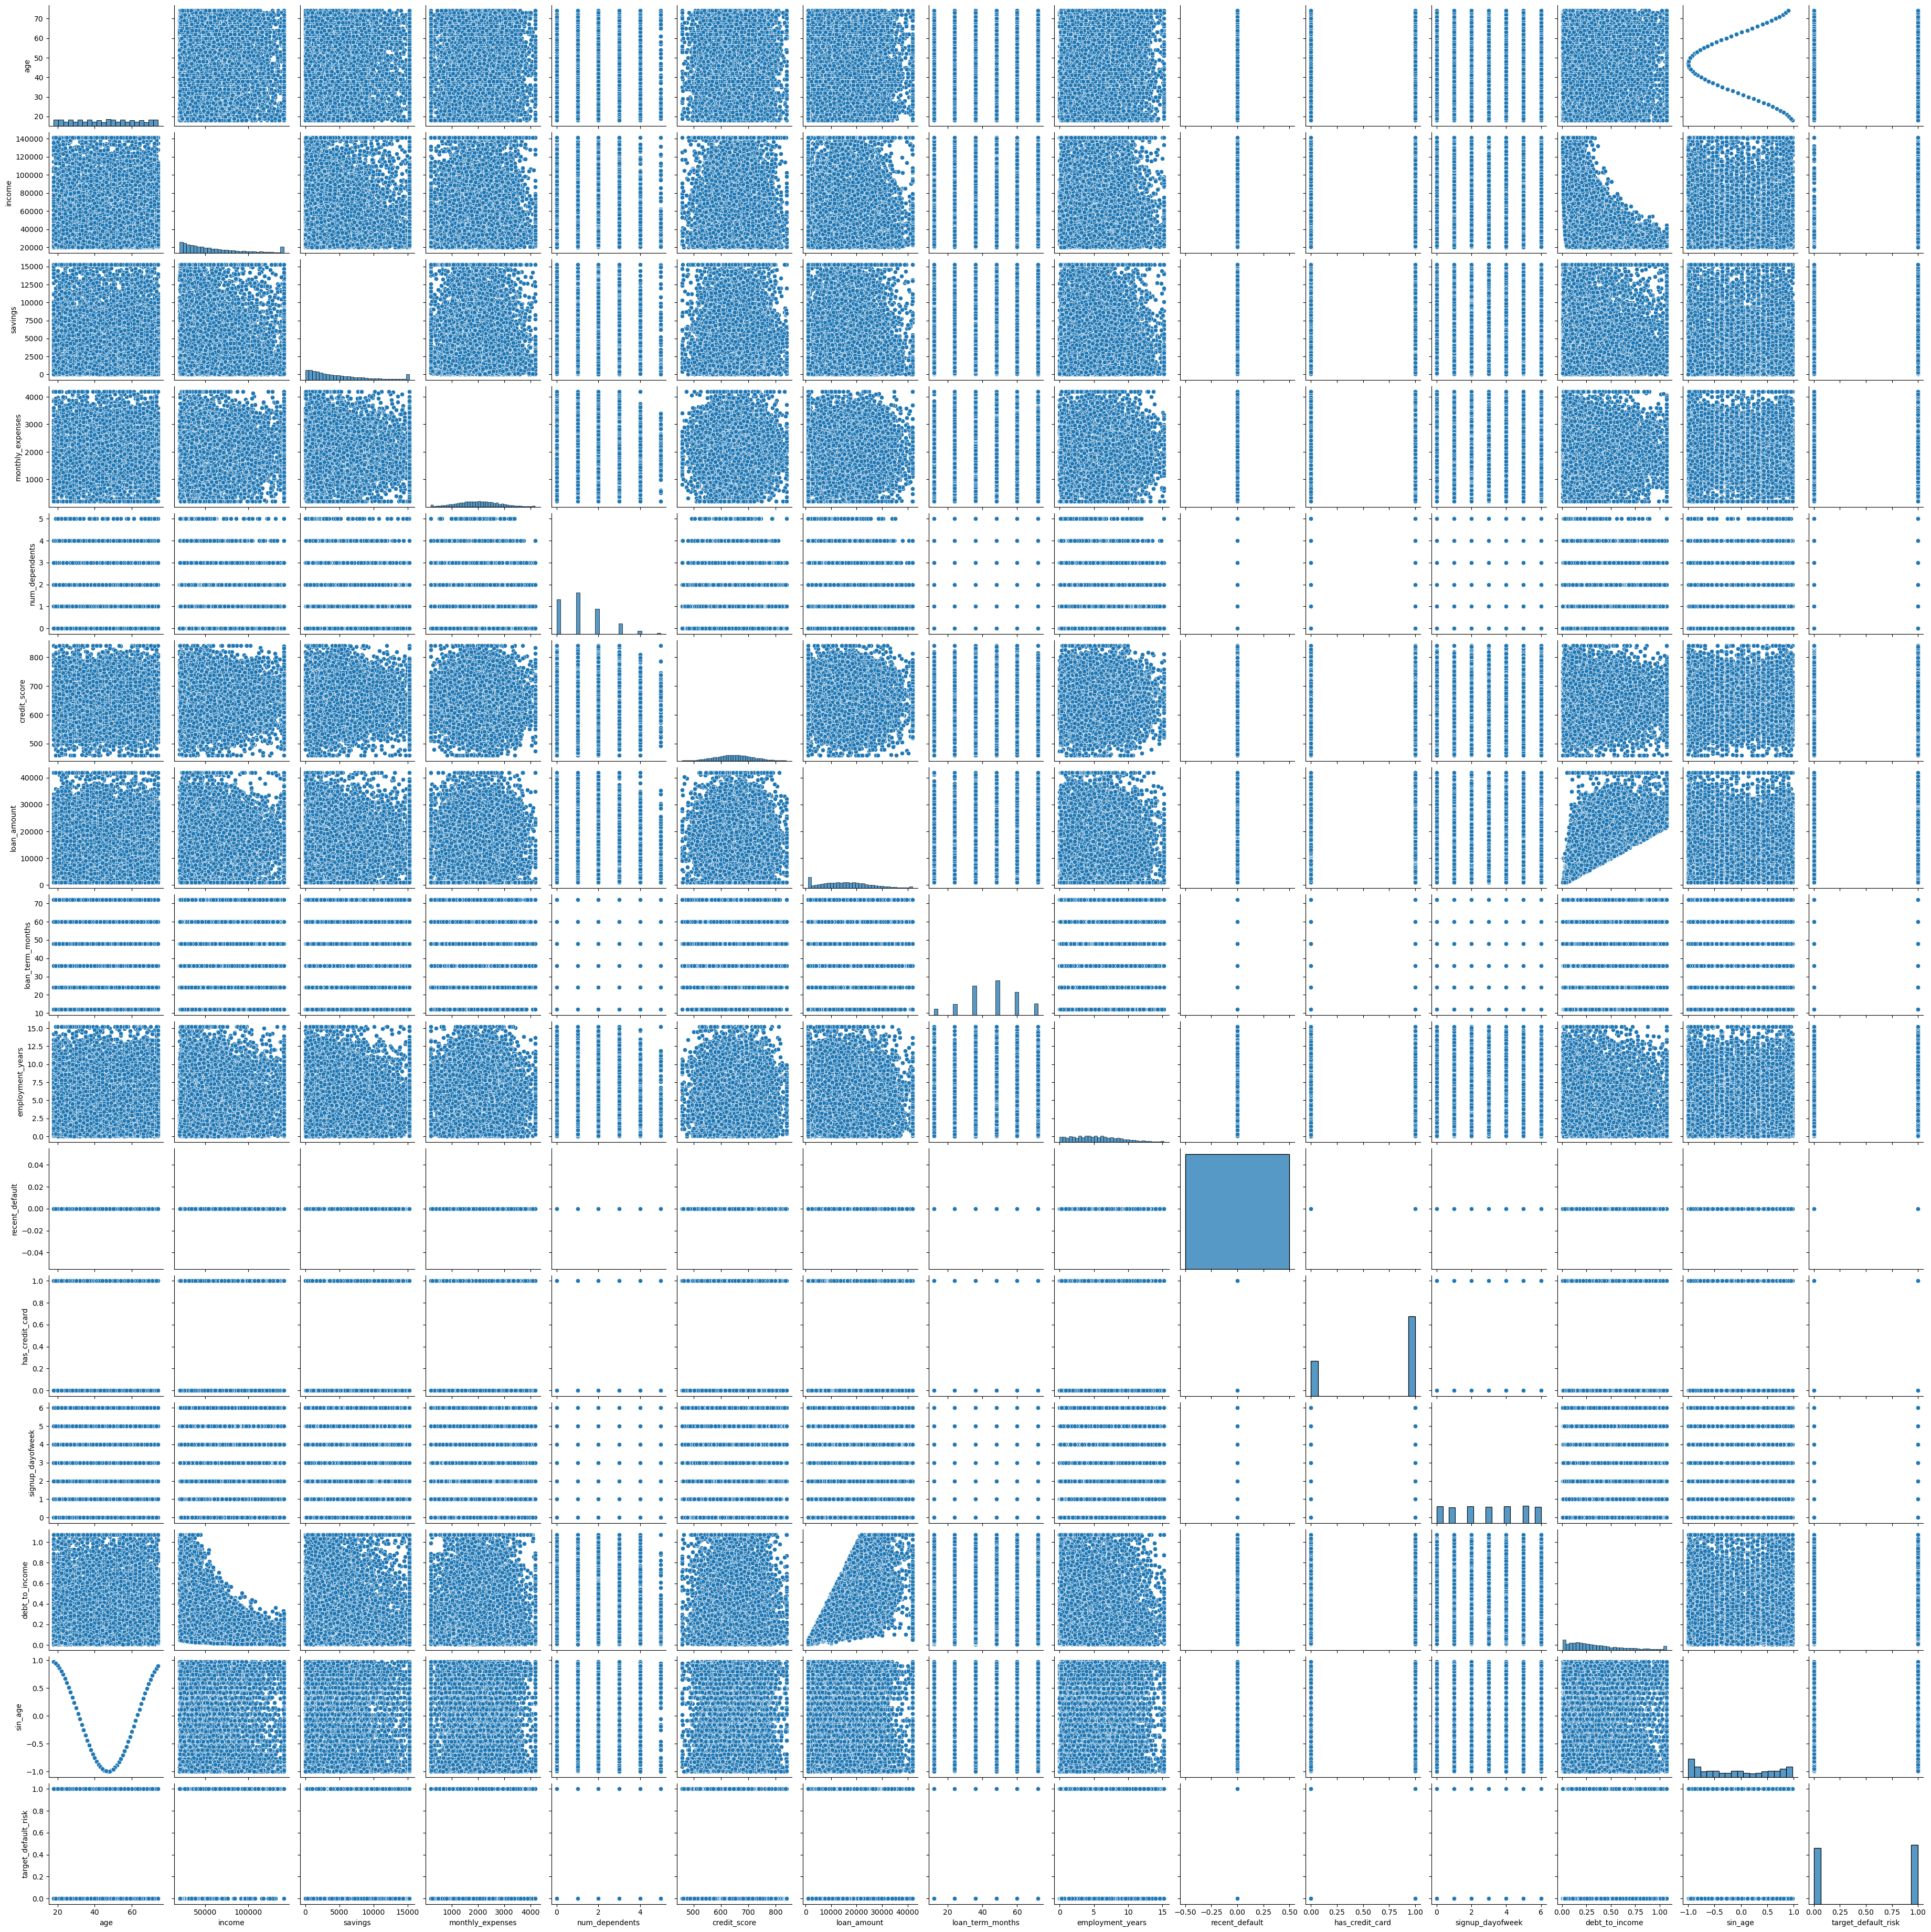

In [39]:
sns.pairplot(df.select_dtypes(include=["int64","float64"]))
plt.show()
# it is a combinaton of (scatter plot, Histogram, Trends)
# Scatter plot = This helps you see relationships, correlations, or clusters between features.
# Histogram = This tells you about skewness, outliers, or whether values are normally distributed.
# Trends = You can spot linear relationships, non-linear relationships, or no relationship at all.You may also notice outliers

In [40]:
df.shape

(10000, 19)

# 2.Data preprocessing

In [41]:
num_cols

Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age'],
      dtype='object')

In [42]:
cat_cols

Index(['home_ownership', 'education', 'marital_status', 'region'], dtype='object')

### pipline(one_hot encoding, Ordinal encoding, scaling)

In [43]:
for i in num_cols:
    print(df[i].value_counts())
    print("\n")
# num_cols list of numerical columns in data df.
# for i in num_cols loops through each numerical columns.
# df[i].value_counts()  counts how many times each unique value appears in that column.

age
73    209
54    209
53    199
36    194
34    192
48    191
46    190
25    189
21    187
20    186
58    186
35    186
49    185
26    185
38    182
32    182
28    182
63    181
74    181
40    180
47    180
70    179
56    178
50    177
19    177
57    177
22    177
42    176
33    174
60    174
24    174
29    174
71    172
64    170
45    170
37    170
61    169
30    169
62    169
31    168
27    168
66    167
23    166
69    166
59    165
72    165
18    165
43    164
52    164
41    164
55    163
68    163
39    162
67    159
51    154
65    148
44    147
Name: count, dtype: int64


income
140959.875    479
21232.000       4
20702.000       4
60685.000       3
40694.000       3
             ... 
45584.000       1
38884.000       1
91754.000       1
25921.000       1
38273.000       1
Name: count, Length: 8631, dtype: int64


savings
15251.0    472
1308.0       8
275.0        7
46.0         6
666.0        6
          ... 
10143.0      1
3665.0       1
9344.0       1
10453.0 

In [44]:
for i in cat_cols:
    print(df[i].value_counts())
    print("\n")

home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64


education
Bachelors    4530
HS           2546
Masters      1962
Other         500
PhD           462
Name: count, dtype: int64


marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64


region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64




In [45]:
df["target_default_risk"] = df["target_default_risk"].astype(int)
# The target_default_risk column care contain in as object like "0", "1" strings or float "0.0", "1.0". Machine learning models expect the target to be numeric not string/float, so that we are converting the flot to int.

In [46]:
# training and testing the features 
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [47]:
X.shape

(10000, 18)

In [48]:
Y.shape

(10000,)

In [49]:
X

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,home_ownership,education,marital_status,region,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,RENT,HS,Single,West,1,1,6,0.404,0.141120
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,RENT,Bachelors,Married,East,0,0,2,0.066,0.808496
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,OWN,Bachelors,Single,East,0,1,2,0.325,0.494113
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,OWN,HS,Married,South,0,1,6,0.719,-0.982453
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,MORTGAGE,Masters,Single,West,0,0,1,0.324,0.898708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,RENT,HS,Single,East,0,1,3,0.699,-0.772764
9996,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,RENT,PhD,Divorced,North,0,0,3,0.435,-0.958924
9997,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,OTHER,HS,Married,West,0,0,4,0.719,-0.916166
9998,44,38273.0,18880.0,1060.0,2,653.277645,1000.0,24,11.4,MORTGAGE,Other,Single,North,0,1,6,0.026,-0.951602


In [50]:
new_columns=cat_cols.drop("education")

In [51]:
X["education"].unique()

array(['HS', 'Bachelors', 'Masters', 'Other', 'PhD'], dtype=object)

In [52]:
new_columns

Index(['home_ownership', 'marital_status', 'region'], dtype='object')

## Pipeline + ColumnTransformer

In [53]:
ordinal=["education"]

In [54]:
ord_cat=["Bachelors","HS","Masters","Other","PhD",]

In [55]:
numeric_transform =Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("Scale",StandardScaler())
])

### For numerical columns (age, income, savings, credit_score, etc.):
### Imputer → replaces missing values with the mean of that column. Prevents errors (models can’t handle NaNs).
### StandardScaler → standardizes all numeric values (mean=0, std=1). Ensures features are on the same scale (important for distance-based models like Logistic Regression, SVM).

In [56]:
nom_transform =Pipeline(steps=[
    ("imputer",SimpleImputer(strategy ="most_frequent")),
    ("oneHot",OneHotEncoder(sparse_output=True,drop = "first"))
])

### For nominal categorical columns (like home_ownership, marital_status, region):

### Imputer → replaces missing values with the most frequent category.Works well because mode is a sensible guess for categories.
### OneHotEncoder → converts categories into dummy variables (0/1).
### drop="first" → avoids dummy variable.

In [57]:
ord_transform =Pipeline(steps=[
    ("imputer",SimpleImputer(strategy ="most_frequent")),
    ("ordinal",OrdinalEncoder(categories=[ord_cat]))
])

### Imputer → fills missing values with the most frequent education.
### OrdinalEncoder → assigns integer values based on ord_cat order.
### Example:   Bachelors → 0    HS → 1    Masters → 2    Other → 3    PhD → 4  (Preserves the “ranking” meaning of education).

In [58]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_transform,num_cols),
        ("cat",nom_transform, new_columns),
        ("ord",ord_transform,ordinal)
    ],remainder ="passthrough"
)

### ColumnTransformer applies the right transformation to each type of column:
### num_cols → numeric preprocessing (impute + scale)
### new_columns → nominal preprocessing (impute + one-hot)
### ordinal → ordinal preprocessing (impute + encode)
### remainder="passthrough" → leaves any other columns as they are (instead of dropping).

In [59]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('Scale', StandardScaler())]),
                                 Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('oneHot',
                                                  OneHotEncoder(drop='first'))]),
                                 Index(['home_ownership', 'marital_status', 'region'], dtype='object')),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Bachelors',
                                                                              'HS',
                                                                              'Masters',
                                                                              'Other',
                                                                              'PhD']]))]),
                                 ['education'])])

In [60]:
preprocessor.fit(X)

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('Scale', StandardScaler())]),
                                 Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('oneHot',
                                                  OneHotEncoder(drop='first'))]),
                                 Index(['home_ownership', 'marital_status', 'region'], dtype='object')),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Bachelors',
                                                                              'HS',
                                                                              'Masters',
                                                                              'Other',
                                                                              'PhD']]))]),
                                 ['education'])])

In [61]:
x_transformed = preprocessor.transform(X)
Features =preprocessor.get_feature_names_out()
new_df=pd.DataFrame(x_transformed,columns=Features)
#1.x_transformed = preprocessor.transform(X)
#A.Runs your preprocessor on the original input X.

#B.Applies:
#1.Numeric imputation + scaling
#2.Nominal imputation + one-hot encoding
#3.Ordinal imputation + ordinal encoding

#C.Models don’t understand raw strings, missing values, or unscaled numbers,so this step ensures everything is numeric, clean, and ready for ML

#=>2.Features = preprocessor.get_feature_names_out()
#A.After transformation, features no longer look like the original dataset.
#B.This gives human-readable names for the transformed columns.

#=>3.new_df = pd.DataFrame(x_transformed, columns=Features)
#A.Wraps the transformed numpy array into a DataFrame with proper column names.
#B.Actually we'll do this to make easier to inspect and debug.
#C.And by doing this You can do feature importance, correlation, visualization with proper column names.

In [62]:
new_df["target_default_risk"]=df["target_default_risk"]
# Attaches the target variable back to the transformed dataset.
# Now new_df contains both processed features and the target column.

# Now we'll re check it again (After Transformin / Scalling / Encoding)

In [63]:
new_df

,num__age,num__income,num__savings,num__monthly_expenses,num__num_dependents,num__credit_score,num__loan_amount,num__loan_term_months,num__employment_years,num__recent_default,...,cat__home_ownership_OWN,cat__home_ownership_RENT,cat__marital_status_Married,cat__marital_status_Single,cat__marital_status_Widowed,cat__region_North,cat__region_South,cat__region_West,ord__education,target_default_risk
0,-0.963811,0.179076,1.232253,0.139223,0.708613,-0.655549,0.668510,0.152381,-0.438552,4.502954,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
1,-1.449922,0.281131,-0.814692,-0.108721,-0.193160,0.481876,-0.717238,-0.623095,-1.375998,-0.222076,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,1.345214,-0.530868,-0.626884,-0.283308,-1.094933,0.114126,-0.222737,1.703334,-0.936570,-0.222076,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,0.190701,-0.781758,0.250695,0.295471,-0.193160,0.833591,0.290172,-0.623095,-0.790094,-0.222076,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0
4,1.709796,0.008926,-0.829402,0.804563,0.708613,-1.241709,0.200437,-0.623095,1.436341,-0.222076,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.494520,-0.387665,0.188428,0.321146,-0.193160,0.719515,0.924964,0.152381,-0.028419,-0.222076,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
9996,0.251465,-0.995861,1.040415,-0.779196,1.610386,0.445261,-0.450088,0.927857,1.231274,-0.222076,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,0
9997,-0.173882,-0.659946,-0.240185,0.351956,-0.193160,0.078634,0.503966,0.927857,-0.321371,-0.222076,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0
9998,-0.113118,-0.546598,2.788922,-0.749853,0.708613,0.045404,-0.946144,-1.398572,1.758588,-0.222076,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0,0


In [64]:
x_transformed

array([[-0.96381126,  0.17907628,  1.23225287, ...,  0.        ,
         1.        ,  1.        ],
       [-1.44992175,  0.28113055, -0.81469169, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.34521355, -0.5308676 , -0.62688383, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.17388172, -0.65994598, -0.240185  , ...,  0.        ,
         1.        ,  1.        ],
       [-0.11311791, -0.54659767,  2.78892218, ...,  0.        ,
         0.        ,  3.        ],
       [-0.96381126, -0.15548736,  0.23396941, ...,  0.        ,
         0.        ,  0.        ]])

In [65]:
new_df.head()

,num__age,num__income,num__savings,num__monthly_expenses,num__num_dependents,num__credit_score,num__loan_amount,num__loan_term_months,num__employment_years,num__recent_default,...,cat__home_ownership_OWN,cat__home_ownership_RENT,cat__marital_status_Married,cat__marital_status_Single,cat__marital_status_Widowed,cat__region_North,cat__region_South,cat__region_West,ord__education,target_default_risk
0,-0.963811,0.179076,1.232253,0.139223,0.708613,-0.655549,0.668510,0.152381,-0.438552,4.502954,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
1,-1.449922,0.281131,-0.814692,-0.108721,-0.193160,0.481876,-0.717238,-0.623095,-1.375998,-0.222076,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,1.345214,-0.530868,-0.626884,-0.283308,-1.094933,0.114126,-0.222737,1.703334,-0.936570,-0.222076,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,0.190701,-0.781758,0.250695,0.295471,-0.193160,0.833591,0.290172,-0.623095,-0.790094,-0.222076,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0
4,1.709796,0.008926,-0.829402,0.804563,0.708613,-1.241709,0.200437,-0.623095,1.436341,-0.222076,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1


In [66]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   num__age                     10000 non-null  float64
 1   num__income                  10000 non-null  float64
 2   num__savings                 10000 non-null  float64
 3   num__monthly_expenses        10000 non-null  float64
 4   num__num_dependents          10000 non-null  float64
 5   num__credit_score            10000 non-null  float64
 6   num__loan_amount             10000 non-null  float64
 7   num__loan_term_months        10000 non-null  float64
 8   num__employment_years        10000 non-null  float64
 9   num__recent_default          10000 non-null  float64
 10  num__has_credit_card         10000 non-null  float64
 11  num__signup_dayofweek        10000 non-null  float64
 12  num__debt_to_income          10000 non-null  float64
 13  num__sin_age     

# 3.Modle Building and 

In [67]:
X_new=new_df.drop("target_default_risk",axis=1)
y_new=new_df["target_default_risk"]

In [68]:
x_train,x_test,y_train,y_test=train_test_split(X_new,y_new,test_size=0.2,random_state=42)

In [69]:
smote = SMOTE (random_state=42)
# It is a over sampling  which generates synthetic examples of the minority class to balance the dataset.
# Machine learning models get biased if classes are imbalanced

In [70]:
smote =SMOTE()
#Here we are just re-initialize SMOTE

In [71]:
x_res, y_res=smote.fit_resample(x_train,y_train)
#x_res, y_res = smote.fit_resample(x_train, y_train) applies the SMOTE algorithm to rebalance your training data.
#The algorithm goes through your training set (x_train and y_train) and identifies the minority class.For each minority class sample, SMOTE finds its nearest neighbors

In [72]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_res.value_counts())

Before SMOTE: target_default_risk
1    4101
0    3899
Name: count, dtype: int64
After SMOTE: target_default_risk
1    4101
0    4101
Name: count, dtype: int64


# Logistic Regression

In [74]:
LR_model=LogisticRegression()
#Initializes a Logistic Regression classifier object in scikit-learn.
# We need to create a model object before training it on data.

In [75]:
LR_model.fit(x_train,y_train)
# Train the model

LogisticRegression()

In [76]:
y_pred=LR_model.predict(x_test)
y_pred
# Uses the trained model to predict class labels for your test set x_tes. Output will be (0s and 1s)

array([0, 0, 1, ..., 0, 1, 0])

In [77]:
# accuracy_score ,precision-score,recall_score,F1_score,Confusion_metrix,Classification_repport this all are combination of evaluation metrics for Classification Data 

In [78]:
acc=accuracy_score(y_test,y_pred)
pre=precision_score(y_test,y_pred)
rcl=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print("Accuracy:",acc)
print("Precision:",pre)
print("Recall:",rcl)
print("F1 score:",f1)
print("Confusion Matrix:",cm)
print("Classification Report:", cr)

Accuracy: 0.929
Precision: 0.950354609929078
Recall: 0.9097963142580019
F1 score: 0.929633300297324
Confusion Matrix: [[920  49]
 [ 93 938]]
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.95      0.93       969
           1       0.95      0.91      0.93      1031

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



# DecisionTreeClassification

In [85]:
DT_model = DecisionTreeClassifier()
DT_model

DecisionTreeClassifier()

In [86]:
DT_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [87]:
y_pred_dt=DT_model.predict(x_test)

In [88]:
acc=accuracy_score(y_test,y_pred_dt)
pre=precision_score(y_test,y_pred_dt)
rcl=recall_score(y_test,y_pred_dt)
f1=f1_score(y_test,y_pred_dt)
cm=confusion_matrix(y_test,y_pred_dt)
cr=classification_report(y_test,y_pred_dt)
print("Accuracy:",acc)
print("Precision:",pre)
print("Recall:",rcl)
print("F1 score:",f1)
print("Confusion Matrix:",cm)
print("Classification Report:", cr)

Accuracy: 0.9245
Precision: 0.9347826086956522
Recall: 0.9175557710960233
F1 score: 0.9260890846793931
Confusion Matrix: [[903  66]
 [ 85 946]]
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.93      0.92       969
           1       0.93      0.92      0.93      1031

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



# SVM(Support Vector Machine)

In [90]:
svm_model = SVC()

In [91]:
svm_model.fit(x_train,y_train)

SVC()

In [92]:
y_pred_svm = svm_model.predict(x_test)

In [93]:
acc=accuracy_score(y_test,y_pred_svm)
pre=precision_score(y_test,y_pred_svm)
rcl=recall_score(y_test,y_pred_svm)
f1=f1_score(y_test,y_pred_svm)
cm=confusion_matrix(y_test,y_pred_svm)
cr=classification_report(y_test,y_pred_svm)
print("Accuracy:",acc)
print("Precision:",pre)
print("Recall:",rcl)
print("F1 score:",f1)
print("Confusion Matrix:",cm)
print("Classification Report:", cr)

Accuracy: 0.9255
Precision: 0.9490835030549898
Recall: 0.903976721629486
F1 score: 0.9259811227024342
Confusion Matrix: [[919  50]
 [ 99 932]]
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.95      0.93       969
           1       0.95      0.90      0.93      1031

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



# RanomForestClassifier

In [95]:
RF_model = RandomForestClassifier()

In [96]:
RF_model.fit(x_train,y_train)

RandomForestClassifier()

In [97]:
y_pred_rf = RF_model.predict(x_test)

In [98]:
acc=accuracy_score(y_test,y_pred_rf)
pre=precision_score(y_test,y_pred_rf)
rcl=recall_score(y_test,y_pred_rf)
f1=f1_score(y_test,y_pred_rf)
cm=confusion_matrix(y_test,y_pred_rf)
cr=classification_report(y_test,y_pred_rf)
print("Accuracy:",acc)
print("Precision:",pre)
print("Recall:",rcl)
print("F1 score:",f1)
print("Confusion Matrix:",cm)
print("Classification Report:", cr)

Accuracy: 0.9405
Precision: 0.9523809523809523
Recall: 0.9311348205625606
F1 score: 0.9416380578715057
Confusion Matrix: [[921  48]
 [ 71 960]]
Classification Report:               precision    recall  f1-score   support

           0       0.93      0.95      0.94       969
           1       0.95      0.93      0.94      1031

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



# XGBClassifier(EXtreame Gradient Boosting)

In [105]:
xgb_model = XGBClassifier()

In [106]:
xgb_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [107]:
y_pred_xgb =xgb_model.predict(x_test)

In [108]:
acc_xgb=accuracy_score(y_test,y_pred_xgb)
print("Accuracy:",acc_xgb)

Accuracy: 0.9615


 # 4.Hyperparameter Tuning(GridSearchCV )

# GridSearch CV OF LogisticRegression

In [80]:
param_grid={
    "penalty":["l1","l2"],
    "C" : [0.01, 0.1, 1, 10, 100],
    "solver":["liblinear","saga"]
}
# The param we are bring from logistic kernal.

In [81]:
grid = GridSearchCV(LR_model,param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [82]:
print("Best parameters:",grid.best_params_)
print("Best cv Score:",grid.best_score_)

Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best cv Score: 0.9262500000000001


In [83]:
best_LR_model=LogisticRegression(C=1, max_iter=100,penalty="l2")
best_LR_model.fit(x_train,y_train)
y_pred =best_LR_model.predict(x_test)
print("Final Accuracy:",accuracy_score(y_test, y_pred))

Final Accuracy: 0.929


# GridSearchCV Of RandomeForestClassifier

In [99]:
param_grid_RFC={
    "n_estimators":[100.300,500],
    "max_depth":[None,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
}

In [100]:
grid_RFC=GridSearchCV(RandomForestClassifier(),param_grid_RFC,scoring="accuracy",cv=5)

In [101]:
grid_RFC.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100.3, 500]},
             scoring='accuracy')

In [102]:
print("Best Parameters:",grid_RFC.best_params_)
print("Best cv Score:",grid_RFC.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Best cv Score: 0.933


In [103]:
best_rf = grid_RFC.best_estimator_
y_pred = best_rf.predict(x_test)
print("Final Accuracy:",accuracy_score(y_test,y_pred))

Final Accuracy: 0.9455


# GridSearchCV Of XGBClassifier

In [109]:
param_grid_XGB = {
    "n-estimators":[100,300,500],
    "max_depth":[3,5,7,10],
    "learning_rate":[0.01,0.1,0.2],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0],
}

In [110]:
grid_XGB = GridSearchCV(estimator= XGBClassifier(),param_grid=param_grid_XGB,scoring="accuracy",cv=5,n_jobs=-1)

In [111]:
grid_XGB.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7, 10],
                         'n-estimators': [100, 300, 500],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy')

In [112]:
print("Best Parameters:", grid_XGB.best_params_)
print("Best CV Score:",grid_XGB.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n-estimators': 100, 'subsample': 1.0}
Best CV Score: 0.95425


In [116]:
best_XGB = grid_XGB.best_estimator_
y_pred = best_XGB.predict(x_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.962


### 